In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ungapped disk

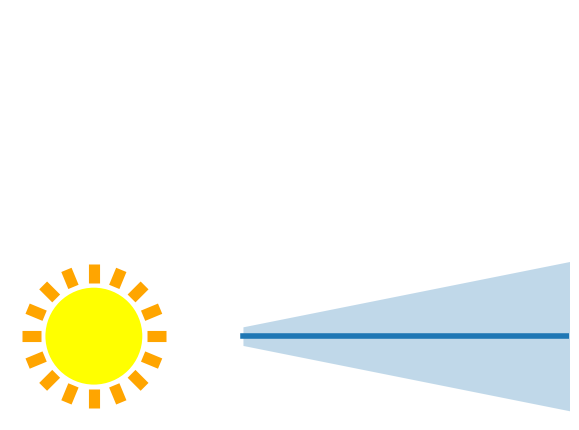

In [36]:
# ---------- disk / warp params ----------
r_in, r_out = 0.2, 2.0
Nr, Nphi     = 256, 64
H_over_R     = 0.2 # 0.08
beta_max     = np.deg2rad(0.0) # 25
r_warp, d_warp = 1., 10

def beta_of_r(r):
    return beta_max * 0.5 * (1.0 + np.tanh((r - r_warp) / d_warp))

# ---------- make warped disk side-view curve ----------
r = np.linspace(r_in, r_out, Nr)
beta = beta_of_r(r)

# Midplane height in the x-z side view.
# Here x ~ r, z = r sin beta.
x = r
z = r * np.sin(beta)

# Disk thickness.  The projected vertical half-thickness is roughly H cos beta.
H = H_over_R * r
z_upper = z + H * np.cos(beta)
z_lower = z - H * np.cos(beta)

# Optional rescaling / shifting to match the cartoon layout
x_plot = 1.25 * x
z_plot = 1.25 * z
zu_plot = 1.25 * z_upper
zl_plot = 1.25 * z_lower

# ---------- figure ----------
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.set_aspect("equal")
ax.axis("off")

# ---------- Sun ----------
sun_center = (-0.55, 0.0)
sun_radius = 0.26

n_rays = 16
for i in range(n_rays):
    ang = 2 * np.pi * i / n_rays
    r1 = 1.10 * sun_radius
    r2 = 1.48 * sun_radius

    ax.plot(
        [sun_center[0] + r1 * np.cos(ang), sun_center[0] + r2 * np.cos(ang)],
        [sun_center[1] + r1 * np.sin(ang), sun_center[1] + r2 * np.sin(ang)],
        color="orange",
        lw=8,
        solid_capstyle="butt",
        zorder=1,
    )

ax.add_patch(
    Circle(
        sun_center,
        sun_radius,
        facecolor="yellow",
        edgecolor="none",
        zorder=2,
    )
)

# ---------- warped disk ----------

ax.fill_between(
    x_plot,
    zl_plot,
    zu_plot,
    color="#8db9d8",
    alpha=0.55,
    linewidth=0,
    zorder=0,
)

ax.plot(
    x_plot,
    z_plot,
    color="#1f77b4",
    lw=4,
    zorder=3,
)

# ---------- limits ----------
ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.45, 1.75)

plt.tight_layout()

plt.savefig("Figures/bent-disk-cartoon.png")

plt.show()

# gapped disk

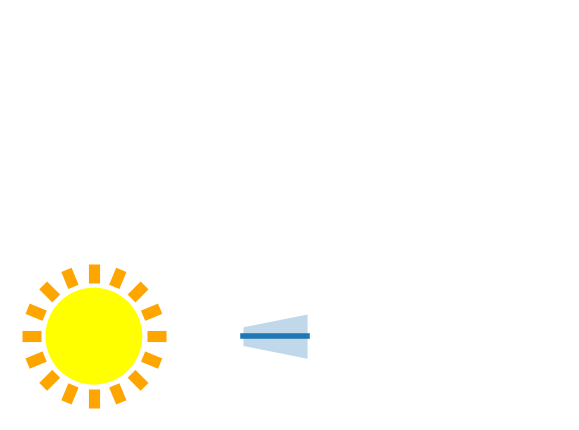

In [39]:
# ---------- disk / warp params ----------
r_in, r_out = 0.2, 2.0
Nr, Nphi     = 256, 64
H_over_R     = 0.2
beta_max     = np.deg2rad(0.0)
r_warp, d_warp = 1., 10

def beta_of_r(r):
    return beta_max * 0.5 * (1.0 + np.tanh((r - r_warp) / d_warp))

# ---------- make warped disk side-view curve ----------
r = np.linspace(r_in, r_out, Nr)
beta = beta_of_r(r)

# Midplane height in the x-z side view.
# Here x ~ r, z = r sin beta.
x = r
z = r * np.sin(beta)

# Disk thickness.  The projected vertical half-thickness is roughly H cos beta.
H = H_over_R * r
z_upper = z + H * np.cos(beta)
z_lower = z - H * np.cos(beta)

# Optional rescaling / shifting to match the cartoon layout
x_plot = 1.25 * x
z_plot = 1.25 * z
zu_plot = 1.25 * z_upper
zl_plot = 1.25 * z_lower

# ---------- figure ----------
fig, ax = plt.subplots(figsize=(10, 4.4))
ax.set_aspect("equal")
ax.axis("off")

# ---------- Sun ----------
sun_center = (-0.55, 0.0)
sun_radius = 0.26

n_rays = 16
for i in range(n_rays):
    ang = 2 * np.pi * i / n_rays
    r1 = 1.10 * sun_radius
    r2 = 1.48 * sun_radius

    ax.plot(
        [sun_center[0] + r1 * np.cos(ang), sun_center[0] + r2 * np.cos(ang)],
        [sun_center[1] + r1 * np.sin(ang), sun_center[1] + r2 * np.sin(ang)],
        color="orange",
        lw=8,
        solid_capstyle="butt",
        zorder=1,
    )

ax.add_patch(
    Circle(
        sun_center,
        sun_radius,
        facecolor="yellow",
        edgecolor="none",
        zorder=2,
    )
)

# ---------- warped disk ----------

i1 = 40
i2 = 150

x_1 = x_plot[:i1]
z_1 = z_plot[:i1]
zl_1 = zl_plot[:i1]
zu_1 = zu_plot[:i1]

# before the gap
ax.fill_between(
    x_1,
    zl_1,
    zu_1,
    color="#8db9d8", alpha=0.55, linewidth=0, zorder=0,
)

ax.plot(
    x_1,
    z_1,
    color="#1f77b4", lw=4, zorder=3,
)

# the gap 
#...

# after the gap
#...

# ---------- limits ----------
ax.set_xlim(-1.0, 2.0)
ax.set_ylim(-0.45, 1.75)

plt.tight_layout()


plt.savefig("Figures/gapped-disk-cartoon.png")

plt.show()